In [12]:
#Imports
import numpy as np
import tensorflow as tf
from tensorflow import keras
import datetime as dt
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

tf.random.set_seed(0)
np.random.seed(0)




[*********************100%***********************]  1 of 1 completed
h:\Python\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


Text(0, 0.5, 'Log Return')

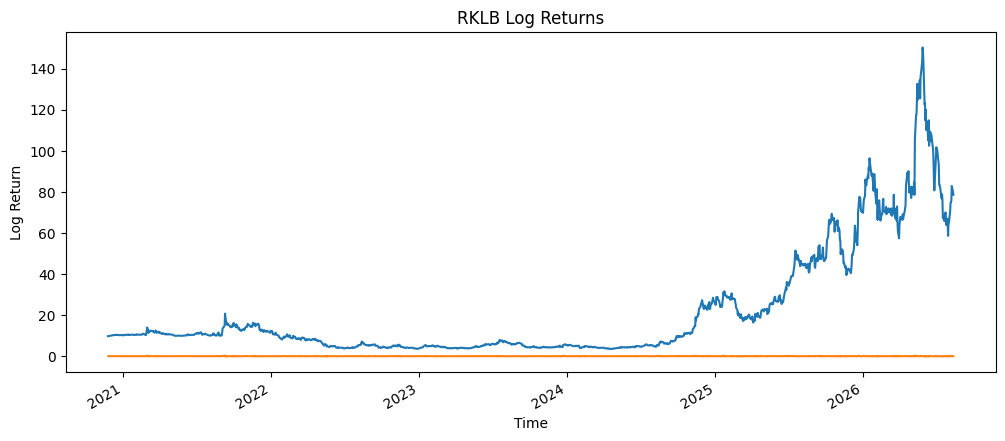

In [13]:
#import data of RKLB from yahoo finance   
ticker = "RKLB"
data = yf.download(ticker, start="2018-01-01", auto_adjust=True)
prices = data["Close"].squeeze().dropna()
plt.figure(figsize=(12, 5))
plt.plot(prices)
plt.title("RKLB Stock Price")
plt.xlabel("Time")
plt.ylabel("Price")
#plt.show()


log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.plot(figsize=(12, 5))
plt.title("RKLB Log Returns")
plt.xlabel("Time")
plt.ylabel("Log Return")
#plt.show()

In [14]:
#1) Market parameters for an european ATM put option for RKLB 
mu_daily = log_returns.mean()
sigma_daily = log_returns.std()

trading_days_per_year = 252
mu = mu_daily * trading_days_per_year
sigma = sigma_daily * np.sqrt(trading_days_per_year)
print(mu, sigma)
option_type = "Put"
S_0 = prices.iloc[-1]
K = S_0
strike = np.float32(K) #ATM option
maturity_days = 31 # set this to any maturity in calendar days
T = maturity_days / trading_days_per_year  # maturity in years
N = maturity_days  # number of hedging time steps 
d = T / N
r = 0.015 #risk-free interest rate
kappa = 0.01
n_train = 40_000
n_test = 10_000
n_paths = n_train + n_test

0.3672352614899976 0.7730034483607954


In [15]:
#2) Simulate stock price paths using Geometric Brownian Motion (GBM)
np.random.seed(0)
d = T / N
Price_mat = np.zeros((N + 1, n_paths))
Price_mat[0,:] = S_0

for i in range(n_paths):
    rand_stdnorm = np.random.randn(N)
    Price_mat[1:,i] = S_0*np.cumprod(np.exp((mu-sigma**2/2)*d + sigma*np.sqrt(d)*rand_stdnorm))

#apply a transformation to stock price
prepro_stock = "Log-moneyness"
if(prepro_stock == "Log"):
    Price_mat = np.log(Price_mat)
elif (prepro_stock == "Log-moneyness"):
    Price_mat = np.log(Price_mat/K)

#Construct train and test sets
train_input = np.zeros((N+1, 40000,2))
test_input = np.zeros((N+1, 10000,2))

time_to_maturity = np.zeros(N+1)
time_to_maturity[1:] = T/N
time_to_maturity = np.cumsum(time_to_maturity)
time_to_maturity = time_to_maturity[::-1]

train_input[:,:,0] = Price_mat[:,:40000]
train_input[:,:,1] = np.reshape(np.repeat(time_to_maturity, train_input.shape[1], axis=0), (N+1, train_input.shape[1]))
test_input[:,:,0] = Price_mat[:,40000:]
test_input[:,:,1] = np.reshape(np.repeat(time_to_maturity, test_input.shape[1], axis=0), (N+1, test_input.shape[1]))


In [16]:
#Fixed hyperparameters for Neural Network
batch_size = 1000
epochs = 100
hidden_layers = 2
nbs_units = 56
lr = 0.0005
alpha = 0.95

In [17]:
# Tensor discount factor
disc_mat = np.zeros((N+1, n_paths, 1))
disc_train = np.zeros((N+1, n_train, 1))
disc_test = np.zeros((N+1, n_test, 1))
discount_vect         = np.ones(disc_mat.shape[0]) 
h = T/N
discount_vect[1:] = np.exp(-r*h)
discount_vect = np.cumprod(discount_vect)
disc_mat = np.reshape(np.repeat(discount_vect, n_paths, axis=0), (N+1, n_paths, 1))
disc_train = disc_mat[:,:n_train,:]
disc_batch = disc_mat[:,:batch_size,:]
disc_test = disc_mat[:,n_train:,:]
disc_mat = []

In [18]:
class DeepAgent(object):
    """
    Inputs:
    nbs_point_traj: if [S_0,...,S_N] ---> nbs_point_traj = N+1
    batch_size    : size of mini-batch
    nbs_input     : number of features (always 2 in this example)
    position_type : {Long, Short}
    hidden_layers : number of hidden layers (doesn't include the output layer)
    nbs_units     : number of neurons per layer
    lr            : learning rate hyperparameter of the Adam optimizer
    prepro_stock  : {Log, Log-moneyness, Nothing} - what transformation was used for stock prices
    name          : name to load the trained neural network once trained
    """
    def __init__(self, nbs_point_traj, batch_size, nbs_input, position_type, hidden_layers, nbs_units, lr, prepro_stock, name, option_type, kappa):

        self.nbs_point_traj = nbs_point_traj
        self.batch_size      = batch_size
        self.nbs_input       = nbs_input
        self.position_type   = position_type
        self.hidden_layers   = hidden_layers
        self.nbs_units       = nbs_units
        self.lr               = lr
        self.prepro_stock    = prepro_stock
        self.option_type     = option_type
        self.model_name      = name   # name of the neural network to save
        self.kappa           = kappa  # proportional transaction cost parameter
        # 4.1) Two hidden layers with relu activation function
        self.layer_1 = tf.keras.layers.Dense(self.nbs_units, tf.nn.relu)
        self.layer_2 = tf.keras.layers.Dense(self.nbs_units, tf.nn.relu)

        # 4.2) Output layer of dimension one (outputs the position in the underlying)
        self.layer_out = tf.keras.layers.Dense(1, None)

        # 8) SGD step with the adam optimizer
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=self.lr)

        # 9) Save the model
        self.saver = tf.train.Checkpoint(layer_1=self.layer_1, layer_2=self.layer_2, layer_out=self.layer_out)

    def compute_loss(self, input, strike, disc_tensor, alpha):

        # 2) Discount prices computation:
        unorm_price    = self.inverse_processing(input[:,:,0], strike)   # Inverse normalization
        discount_price = tf.multiply(unorm_price, disc_tensor[:,:,0])    # exp(-rh*n)*S_{n}
        inc_disc_ret   = discount_price[1:,:] - discount_price[0:-1,:]   # Increment of discount returns

        # 3) Payoff of each path for an ATM put option
        if self.option_type == "Put":
            payoff = tf.maximum(strike - unorm_price[-1,:], 0)
        elif (self.option_type == "Call"):
            payoff = tf.maximum(unorm_price[-1,:] - strike, 0)

        # 4.3) Compute hedging strategies for all time-steps
        V_t    = tf.zeros(self.batch_size)  # initial portfolio value is always zero
        delta_prev    = tf.zeros(self.batch_size)          
        disc_cost_sum = tf.zeros(self.batch_size)          
        deltas = tf.zeros(shape = [self.nbs_point_traj-1, self.batch_size, 1], dtype=tf.float32)
        for t in range(self.nbs_point_traj-1):

            # input of the FFNN at time 't': [S_t, T-t, V_t]
            input_t = tf.concat([input[t,:,:], tf.expand_dims(V_t, axis = 1)], axis=1)

            # forward prop at time 't'
            layer = self.layer_1(input_t)
            layer = self.layer_2(layer)
            layer = self.layer_out(layer)

            # Compile the trading strategies
            if (t==0):
                # At t = 0, need to expand the dimension to have [nbs_point_traj, batch_size, 1]
                deltas = tf.expand_dims(layer, axis=0)      # [1, batch_size, 1]
            else:
                deltas = tf.concat([deltas, tf.expand_dims(layer, axis = 0)], axis = 0)
            delta_t = deltas[t,:,0] 
            cost_t = self.kappa * unorm_price[t,:] * tf.abs(delta_t - delta_prev)

            # Compute the portfolio value for the next period
            factor  = tf.divide(disc_tensor[t,:,0], disc_tensor[t+1,:,0])  # equals exp(rh)
            V_t_pre = V_t
            # Update rule from Godin (2016), see eq. (1)
            V_t     = V_t_pre*factor + delta_t*(unorm_price[t+1,:] - unorm_price[t,:]*factor) - cost_t
            disc_cost_sum = disc_cost_sum + disc_tensor[t,:,0] * cost_t
            delta_prev = delta_t

        # 5) Compute the discounted gain at maturity for each paths
        cumulative_factor = tf.math.reciprocal(disc_tensor[-1,:,0])            # Project from 0 to T
        disc_gain          = tf.reduce_sum(inc_disc_ret*deltas[:,:,0], axis=0)  # G_{N}
        disc_gain          = disc_gain - disc_cost_sum
        
        # 6) Compute hedging errors for each paths as if initial portfolio value is zero
        if(self.position_type == 'Short'):
            hedging_err = payoff - cumulative_factor*disc_gain
        elif(self.position_type == 'Long'):
            hedging_err = - payoff - cumulative_factor*disc_gain

        # 7) Compute the CVaR_{alpha} on the batch of hedging error
        # - This is the empirical cost functions estimated with a mini-batch
        # - Equivalent to estimator of CVaR_{alpha} presented in the paper of Carbonneau and Godin (2020)
        #   since alpha*N_{batch} is an integer in this example
        loss = tf.reduce_mean(tf.sort(hedging_err)[tf.cast(alpha*self.batch_size,tf.int32):])

        return loss, hedging_err, deltas

    # Function to compute the CVaR_{alpha} outside the optimization, i.e. at the end of each epoch in this case
    def loss_out_optim(self, hedging_err, alpha):
        loss = np.mean(np.sort(hedging_err)[int(alpha*hedging_err.shape[0]):])
        return loss

    # Given a type of preprocessing, reverse the processing of the stock price
    def inverse_processing(self, paths, strike):
        if (self.prepro_stock =="Log-moneyness"):
            paths = tf.multiply(strike, tf.exp(paths))
        elif (self.prepro_stock == "Log"):
            paths = tf.exp(paths)
        return paths


    @tf.function
    def train_step(self, input, strike, disc_tensor, alpha):
        with tf.GradientTape() as tape:
            loss, hedging_err, _ = self.compute_loss(input, strike, disc_tensor, alpha)
        trainable_vars = self.layer_1.trainable_variables + self.layer_2.trainable_variables + self.layer_out.trainable_variables
        grads = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(grads, trainable_vars))
        return hedging_err

    # ---------------------------------------------------------------------------------------#
    # Function to call the deep hedging algorithm batch-wise
    # Disclosure: function adapted from https://github.com/mgroncki/DataScienceNotebooks/blob/master/DeepHedging/DeepHedging_Part1.ipynb
    """
    Input:
     - paths       : tensor of features of dimension [n_timesteps+1, n_sims, nbs_features]
     - strikes     : vector of strike prices of dimension [N_batch]
     - disc_batch  : tensor of discount factors of dimension [n_timesteps+1, N_batch, 1]
     - alpha       : level of risk aversion of the hedger
     - epochs      : total number of epochs to run
    """
    def train_deephedging(self, paths, strikes, disc_batch, alpha, epochs):
        sample_size       = paths.shape[1]               # total number of paths in the train set
        batch_size        = self.batch_size
        idx               = np.arange(sample_size)       # [0,1,...,sample_size-1]
        start             = dt.datetime.now()            # Time-to-train
        self.loss_epochs  = 9999999*np.ones(epochs)      # Store the loss at the end of each epoch for the train
        epoch             = 0

        # Loop for each epoch until the maximum number of epochs
        while (epoch < epochs):
            hedging_err_train = []  # Store hedging errors obtained for one complete epoch
            np.random.shuffle(idx)  # Randomize the dataset (not useful in this case since dataset is simulated iid)

            # loop over each batch size
            for i in range(int(sample_size/batch_size)):

                # Indexes of paths used for the mini-batch
                indices = idx[i*batch_size : (i+1)*batch_size]

                # SGD step
                input_batch = tf.constant(paths[:,indices,:], dtype=tf.float32)
                disc_tensor = tf.constant(disc_batch[:,indices,:], dtype=tf.float32)
                hedging_err = self.train_step(input_batch, strikes, disc_tensor, alpha)

                hedging_err_train.append(hedging_err.numpy())

            # Store the loss on the train set after each epoch for learning curve
            self.loss_epochs[epoch] = self.loss_out_optim(np.concatenate(hedging_err_train), alpha)

            # Print the CVaR value at the end of each epoch
            print('Time elapsed:', dt.datetime.now()-start)
            print('Epoch %d, CVaR - Train: %.3f' % (epoch+1, self.loss_epochs[epoch]))

            epoch+=1  # increment the epoch

        # End of training
        print("---Finished training results---")
        print('Time elapsed:', dt.datetime.now()-start)
        self.saver.save(r"./Models/%s/model" % self.model_name)


        # Return the learning curve
        return self.loss_epochs

    # Function which will call the deep hedging optimization batchwise
    def training(self, paths, strikes, disc_batch, riskaversion, epochs):
        loss_train_epoch = self.train_deephedging(paths, strikes, disc_batch, riskaversion, epochs)
        return loss_train_epoch

    # ---------------------------------------------------------------------- #
    # Function to compute the hedging strategies of a trained neural network
    # - Doesn't train the neural network, only outputs the hedging strategies
    def predict(self, paths, strikes, disc_paths, alpha):
        sample_size = paths.shape[1]
        batch_size  = self.batch_size
        idx         = np.arange(sample_size)  # [0,1,...,sample_size-1]
        strategy_pred = [] # hedging strategies

        # loop over sample size to do one complete epoch
        for i in range(int(sample_size/batch_size)):

            # mini-batch of paths (even if not training to not get memory issue)
            indices = idx[i*batch_size : (i+1)*batch_size]
            input_batch = tf.constant(paths[:,indices,:], dtype=tf.float32)
            disc_tensor = tf.constant(disc_paths[:,indices,:], dtype=tf.float32)
            _, _, strategy = self.compute_loss(input_batch, strikes, disc_tensor, alpha)

            # Append the batch of hedging strategies
            strategy_pred.append(strategy.numpy())
        return np.concatenate(strategy_pred,axis=1)

    def restore(self, checkpoint_path):
        self.saver.restore(checkpoint_path)


In [19]:
#Functions to compute measured risk exposure
"""
Input:
- deltas       : (time step x nbs of paths)
- paths        : (time step x nbs of paths)
- disc_paths   : (time step x nbs of paths x 1)
- strike       : strike price of the option
- alpha        : risk-aversion level for the CVaR computation
- position_type: {Long, Short}
- prepro_stock : {Log, Log-moneyness, Nothing} - what transformation was used for stock prices
"""
#-------------------------------------------------------------------------------------------------#
def measured_risk_exposures(deltas, paths, disc_paths, strike, alpha, position_type, prepro_stock, option_type):

    # De-normalize the stock price process
    if (prepro_stock == "Log"):
        paths = np.exp(paths)
    elif (prepro_stock == "Log-moneyness"):
        paths = strike * np.exp(paths)

    # Discounted prices and returns for each path at each time-step
    discount_price = np.multiply(paths, disc_paths[:, :, 0])          # exp(-rh*n)*S_{n}
    inc_disc_ret   = discount_price[1:, :] - discount_price[0:-1, :]  # Increment of discounted returns

    # Option payoff of the vanilla ATM put
    if (option_type == 'Put'):
        option_payoff = np.maximum(strike - paths[-1, :], 0)
    elif (option_type == 'Call'):
        option_payoff = np.maximum(paths[-1, :] - strike, 0)

    # Discounted gain process
    disc_gain          = np.sum(deltas * inc_disc_ret, axis=0)  # G_{N}
    delta_prev = np.zeros(deltas.shape[1])
    disc_cost_sum = np.zeros(deltas.shape[1])
    for t in range(deltas.shape[0]):
        cost_t = kappa * paths[t, :] * np.abs(deltas[t, :] - delta_prev)
        disc_cost_sum += disc_paths[t, :, 0] * cost_t
        delta_prev = deltas[t, :]
    disc_gain = disc_gain - disc_cost_sum
    
    cumulative_factor  = np.reciprocal(disc_paths[-1, :, 0])    # B_{N}

    if (position_type == 'Short'):
        hedging_err = option_payoff - cumulative_factor * disc_gain
    elif (position_type == 'Long'):
        hedging_err = -option_payoff - cumulative_factor * disc_gain

    # Empirical CVaR at level alpha
    loss = np.mean(np.sort(hedging_err)[int(alpha * hedging_err.shape[0]):])

    return loss

Hyperparameters: learning rate=0.0005, layers=2, neurons=56
---Training start---
Time elapsed: 0:00:10.150672
Epoch 1, CVaR - Train: 33.247
Time elapsed: 0:00:11.313550
Epoch 2, CVaR - Train: 26.896
Time elapsed: 0:00:12.532720
Epoch 3, CVaR - Train: 20.053
Time elapsed: 0:00:13.671115
Epoch 4, CVaR - Train: 14.995
Time elapsed: 0:00:14.685908
Epoch 5, CVaR - Train: 14.268
Time elapsed: 0:00:15.693365
Epoch 6, CVaR - Train: 14.042
Time elapsed: 0:00:16.667197
Epoch 7, CVaR - Train: 14.025
Time elapsed: 0:00:17.771313
Epoch 8, CVaR - Train: 13.854
Time elapsed: 0:00:18.792587
Epoch 9, CVaR - Train: 13.845
Time elapsed: 0:00:19.827868
Epoch 10, CVaR - Train: 13.742
Time elapsed: 0:00:20.859561
Epoch 11, CVaR - Train: 13.666
Time elapsed: 0:00:21.869019
Epoch 12, CVaR - Train: 13.557
Time elapsed: 0:00:22.834056
Epoch 13, CVaR - Train: 13.354
Time elapsed: 0:00:23.886026
Epoch 14, CVaR - Train: 13.316
Time elapsed: 0:00:24.973959
Epoch 15, CVaR - Train: 13.277
Time elapsed: 0:00:26.013525

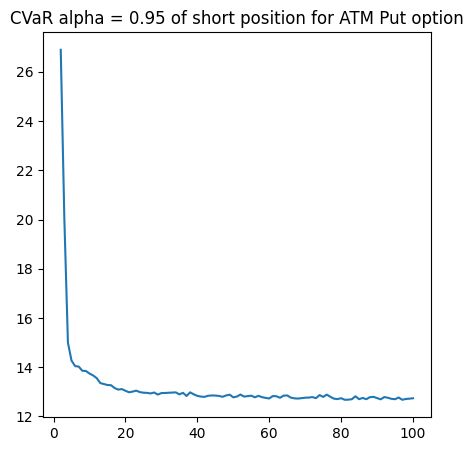

Measured risk exposure of short position on train set: 12.7655
Measured risk exposure of short position on test set: 12.7718


In [20]:
#Short measured risk exposure 
position_type = 'Short'
model_name    = "Short_FFNN"
print("Hyperparameters: learning rate=%.4f, layers=%d, neurons=%d" % (lr, hidden_layers, nbs_units))

# Compile the neural network
FFNN_short = DeepAgent(train_input.shape[0], batch_size, train_input.shape[2], position_type, hidden_layers,
                        nbs_units, lr, prepro_stock, model_name, option_type, kappa)

# Start training
start = dt.datetime.now()
print('---Training start---')
loss_train_epoch = FFNN_short.training(train_input, strike, disc_train, alpha, epochs)
print('---Training end---')

# Plot the learning curve on the train set, i.e. the CVaR on the train set at the end of each epoch
lin_nb_epoch = np.linspace(1, loss_train_epoch.shape[0], loss_train_epoch.shape[0])
fig = plt.figure(figsize=(5, 5), dpi=100)
plt.plot(lin_nb_epoch[1:], loss_train_epoch[1:])
plt.title(f'CVaR alpha = 0.95 of short position for ATM {option_type} option')
plt.show()

# Compute hedging strategies on the training set
delta_short_train = FFNN_short.predict(train_input, strike, disc_train, alpha)

# Compute CVaR 95% on the train set
CVaR_95_short_train = measured_risk_exposures(delta_short_train[:,:,0], train_input[:,:,0], disc_train, strike, alpha, position_type, prepro_stock, option_type)

# Compute hedging strategies on the test set
delta_short_test = FFNN_short.predict(test_input, strike, disc_test, alpha)

# Compute CVaR 95% on the test set
CVaR_95_short_test = measured_risk_exposures(delta_short_test[:,:,0], test_input[:,:,0], disc_test,
                        strike, alpha, position_type, prepro_stock, option_type)
print("Measured risk exposure of short position on train set: %.4f" % (CVaR_95_short_train))
print("Measured risk exposure of short position on test set: %.4f" % (CVaR_95_short_test))

Hyperparameters: learning rate=0.0005, layers=2, neurons=56
---Training start---
Time elapsed: 0:00:07.199426
Epoch 1, CVaR - Train: 21.407
Time elapsed: 0:00:08.258881
Epoch 2, CVaR - Train: 0.087
Time elapsed: 0:00:09.267195
Epoch 3, CVaR - Train: -0.145
Time elapsed: 0:00:10.257078
Epoch 4, CVaR - Train: -0.250
Time elapsed: 0:00:11.231834
Epoch 5, CVaR - Train: -0.420
Time elapsed: 0:00:12.251920
Epoch 6, CVaR - Train: -0.693
Time elapsed: 0:00:13.356964
Epoch 7, CVaR - Train: -1.141
Time elapsed: 0:00:14.463126
Epoch 8, CVaR - Train: -1.416
Time elapsed: 0:00:15.504292
Epoch 9, CVaR - Train: -1.619
Time elapsed: 0:00:16.513418
Epoch 10, CVaR - Train: -1.857
Time elapsed: 0:00:17.531704
Epoch 11, CVaR - Train: -2.099
Time elapsed: 0:00:18.496031
Epoch 12, CVaR - Train: -2.479
Time elapsed: 0:00:19.479978
Epoch 13, CVaR - Train: -2.721
Time elapsed: 0:00:20.463160
Epoch 14, CVaR - Train: -2.820
Time elapsed: 0:00:21.450339
Epoch 15, CVaR - Train: -2.953
Time elapsed: 0:00:22.445810


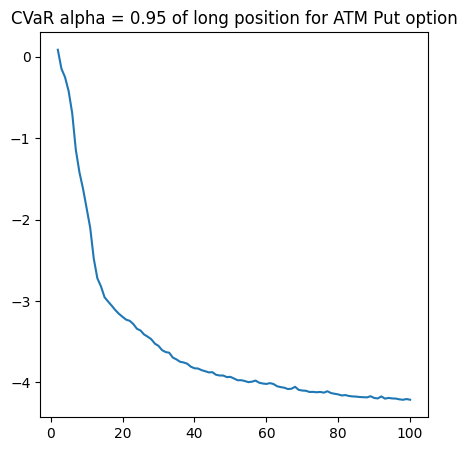

Measured risk exposure of long position on train set: -4.2229
Measured risk exposure of long position on test set: -4.1399


In [21]:
#Long measured risk exposure
position_type = 'Long'
model_name    = "Long_FFNN"
print("Hyperparameters: learning rate=%.4f, layers=%d, neurons=%d" % (lr, hidden_layers, nbs_units))

# Compile the neural network
FFNN_long = DeepAgent(train_input.shape[0], batch_size, train_input.shape[2], position_type, hidden_layers,
                       nbs_units, lr, prepro_stock, model_name, option_type, kappa)

# Start training
start = dt.datetime.now()
print('---Training start---')
loss_train_epoch = FFNN_long.training(train_input, strike, disc_train, alpha, epochs)
print('---Training end---')

# Plot the learning curve on the train set, i.e. the CVaR on the train set at the end of each epoch
lin_nb_epoch = np.linspace(1, loss_train_epoch.shape[0], loss_train_epoch.shape[0])
fig = plt.figure(figsize=(5, 5), dpi=100)
plt.plot(lin_nb_epoch[1:], loss_train_epoch[1:])
plt.title(f'CVaR alpha = 0.95 of long position for ATM {option_type} option')
plt.show()

# Compute hedging strategies on the training set
delta_long_train = FFNN_long.predict(train_input, strike, disc_train, alpha)

# Compute CVaR 95% on the train set
CVaR_95_long_train = measured_risk_exposures(delta_long_train[:,:,0], train_input[:,:,0], disc_train, strike, alpha, position_type, prepro_stock, option_type)

# Compute hedging strategies on the test set
delta_long_test = FFNN_long.predict(test_input, strike, disc_test, alpha)

# Compute CVaR 95% on the test set
CVaR_95_long_test = measured_risk_exposures(delta_long_test[:,:,0], test_input[:,:,0], disc_test,
                        strike, alpha, position_type, prepro_stock, option_type)
print(f"Measured risk exposure of long position on train set: {CVaR_95_long_train:.4f}")
print(f"Measured risk exposure of long position on test set: {CVaR_95_long_test:.4f}")

Ideal stock position today, Short Put: -0.4009 shares per option written
Ideal stock position today, Long Put:  0.4176 shares per option held
Equal risk price of ATM Put of 31 days: 8.4403
Residual hedging risk of ATM Put of 31 days: 4.3160


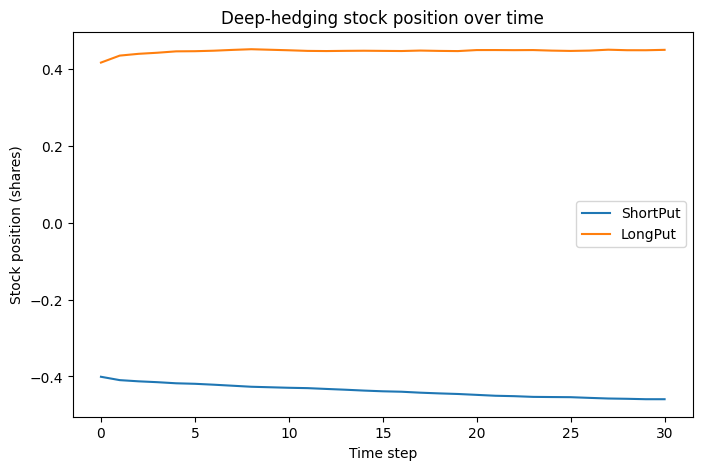

In [22]:
#optimized positions and ERP price
short_delta_today = delta_short_test[0, 0, 0]
long_delta_today  = delta_long_test[0, 0, 0]

print(f"Ideal stock position today, Short {option_type}: {short_delta_today:.4f} shares per option written")
print(f"Ideal stock position today, Long {option_type}:  {long_delta_today:.4f} shares per option held")

ERP     = (CVaR_95_short_test - CVaR_95_long_test)/(2*np.exp(r*T))
epsilon = (CVaR_95_long_test + CVaR_95_short_test)/2
maturity_days = int(round(T * trading_days_per_year))
print(f"Equal risk price of ATM {option_type} of {maturity_days} days: {ERP:.4f}")
print(f"Residual hedging risk of ATM {option_type} of {maturity_days} days: {epsilon:.4f}")

mean_delta_short = delta_short_test[:, :, 0].mean(axis=1)
mean_delta_long  = delta_long_test[:, :, 0].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(mean_delta_short, label= "Short"+ option_type)
plt.plot(mean_delta_long, label= "Long"+ option_type)
plt.xlabel("Time step")
plt.ylabel("Stock position (shares)")
plt.title("Deep-hedging stock position over time")
plt.legend()
plt.show()